# Lab 1.3 — Decision Tree Classifier: Which Counties Have Unhealthy Air?

*Course 1258 — Applied AI for Government IT Professionals · Ch01 AI and ML
Foundations for Government · 30 minutes (flex — your instructor may skip
this) · CloudShare VM (JupyterLab) · pandas + scikit-learn + matplotlib —
no API key needed*

In Lab 1.2 you grouped counties *without* labels (clustering). This time
we **have** a label: did the county record any unhealthy air days in
2024? That makes this a supervised problem — and a decision tree is the
most explainable supervised model there is. You can **draw it, read the
rules out loud, and defend every split to a reviewer** — which is exactly
what a government audit demands.

## Objectives

By the end of this lab, you will:

- Train a decision tree classifier on a real EPA dataset.
- Visualize the tree and read its decision rules in plain English.
- Measure accuracy honestly with a train/test split.
- Watch overfitting appear as the tree grows deeper — and control it.
- Explain feature *leakage* and why some columns must be left out.

## Setup

- **Dataset:** `data/epa_aqi_by_county.csv` — EPA annual Air Quality Index
  by county, 2024: one row per county, days spent at each AQI level plus
  summary statistics. Provenance in `data/MANIFEST.json`.
- **Tools:** pandas, scikit-learn (`DecisionTreeClassifier`, `plot_tree`),
  matplotlib. Run from the `labs/` folder.
- **No API key is needed** — this lab never calls a model.
- **The one rule that never changes:** public or synthetic data only.
- Cells marked `# YOUR CODE` are for you to complete. Each has a reference
  fallback that runs if you leave it blank.

## Steps

1. **(4 min)** Load the EPA summary and build the label. How many counties
   had *any* unhealthy days?
2. **(4 min)** Choose the features — and deliberately leave some out
   (leakage).
3. **(4 min)** Split train/test and fit a depth-3 tree.
4. **(3 min)** Score it: accuracy and a confusion matrix.
5. **(5 min)** **Draw the tree** — the centerpiece. Read the root split.
6. **(4 min)** Feature importances and the rules as text.
7. **(4 min)** Grow the tree all the way: watch it memorize.
8. **(4 min)** Sweep the depth, find the sweet spot, and defend your pick.

### Step 1 — Load the data and build the label (provided)

The label: `has_unhealthy` = 1 if the county recorded **one or more**
"Unhealthy Days" in 2024. First look at the class balance — it decides
what "good accuracy" even means.

997 counties | 151 with unhealthy days (15%)


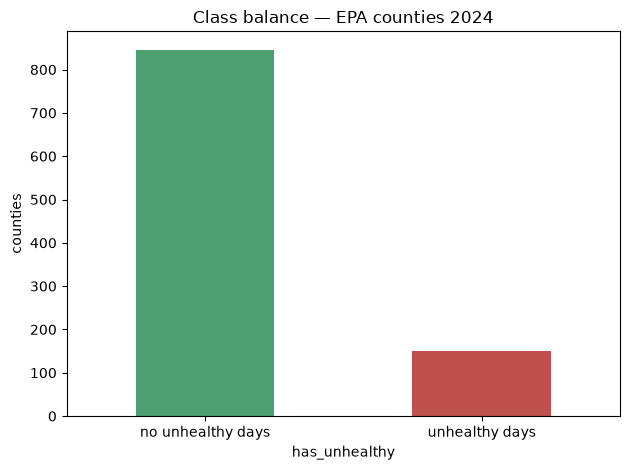

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

aqi = pd.read_csv("data/epa_aqi_by_county.csv")
aqi["has_unhealthy"] = (aqi["Unhealthy Days"] > 0).astype(int)

counts = aqi["has_unhealthy"].value_counts().sort_index()
print(f"{len(aqi)} counties | {counts[1]} with unhealthy days "
      f"({counts[1] / len(aqi):.0%})")

counts.rename({0: "no unhealthy days", 1: "unhealthy days"}) \
      .plot.bar(color=["#4c9f70", "#c0504d"], rot=0,
                ylabel="counties", title="Class balance — EPA counties 2024")
plt.tight_layout(); plt.show()

**Read the chart:** only ~15% of counties have any unhealthy days. A model
that *always* says "no" is already 85% accurate — and useless. Keep that
baseline in mind when you judge Step 4.

### Step 2 — Choose features, and leave the cheaters out (provided)

Some columns must not be features: `Unhealthy Days` **is** the label, and
`Very Unhealthy Days`, `Hazardous Days`, `Max AQI`, and
`90th Percentile AQI` describe the same bad tail. Feeding them in is
called **leakage** — the model "learns" the answer key, scores near 100%,
and tells you nothing. We keep the honest predictors: how many days were
measured, how many were good or moderate, the *median* AQI (typical day,
not the tail), and the per-pollutant day counts.

In [2]:
FEATURES = ["Days with AQI", "Good Days", "Moderate Days", "Median AQI",
            "Days CO", "Days NO2", "Days Ozone", "Days PM2.5", "Days PM10"]
LEAKERS = ["Unhealthy Days", "Very Unhealthy Days", "Hazardous Days",
           "Max AQI", "90th Percentile AQI"]

X = aqi[FEATURES]
y = aqi["has_unhealthy"]
print(f"{len(FEATURES)} features kept | {len(LEAKERS)} columns excluded "
      f"as leakage")

9 features kept | 5 columns excluded as leakage


### Step 3 — Split and fit a small tree (provided)

Hold out 25% of counties the model **never sees in training** — the test
score on those is the only accuracy you may quote. We cap the tree at
depth 3 so it stays drawable and readable.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
print(f"trained on {len(X_train)} counties, testing on {len(X_test)} "
      f"| tree depth {tree.get_depth()}, {tree.get_n_leaves()} leaves")

trained on 747 counties, testing on 250 | tree depth 3, 7 leaves


### Step 4 — Score it (provided)

Accuracy first — then the confusion matrix, because with a 15% positive
class you need to see *which* mistakes the model makes. Missing a county
with unhealthy air (false negative) is the expensive error for a program
office.

train accuracy: 0.886
test  accuracy: 0.860


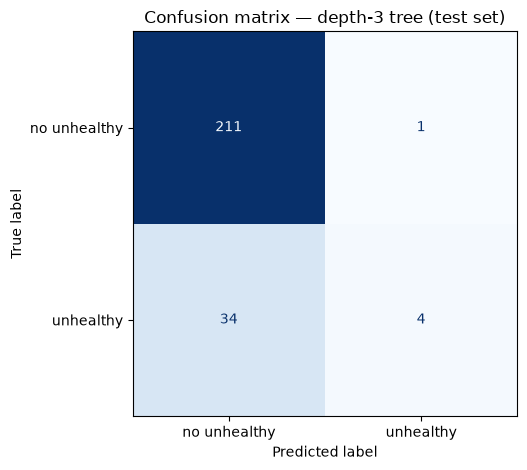

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay

print(f"train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"test  accuracy: {tree.score(X_test, y_test):.3f}")

ConfusionMatrixDisplay.from_estimator(
    tree, X_test, y_test, cmap="Blues", colorbar=False,
    display_labels=["no unhealthy", "unhealthy"])
plt.title("Confusion matrix — depth-3 tree (test set)")
plt.tight_layout(); plt.show()

### Step 5 — Draw the tree (provided)

This is the graphic a reviewer can actually audit. Each box shows the
split rule, the class counts, and the majority class (color). **Read the
root split:** which feature did the tree judge most informative, and at
what threshold?

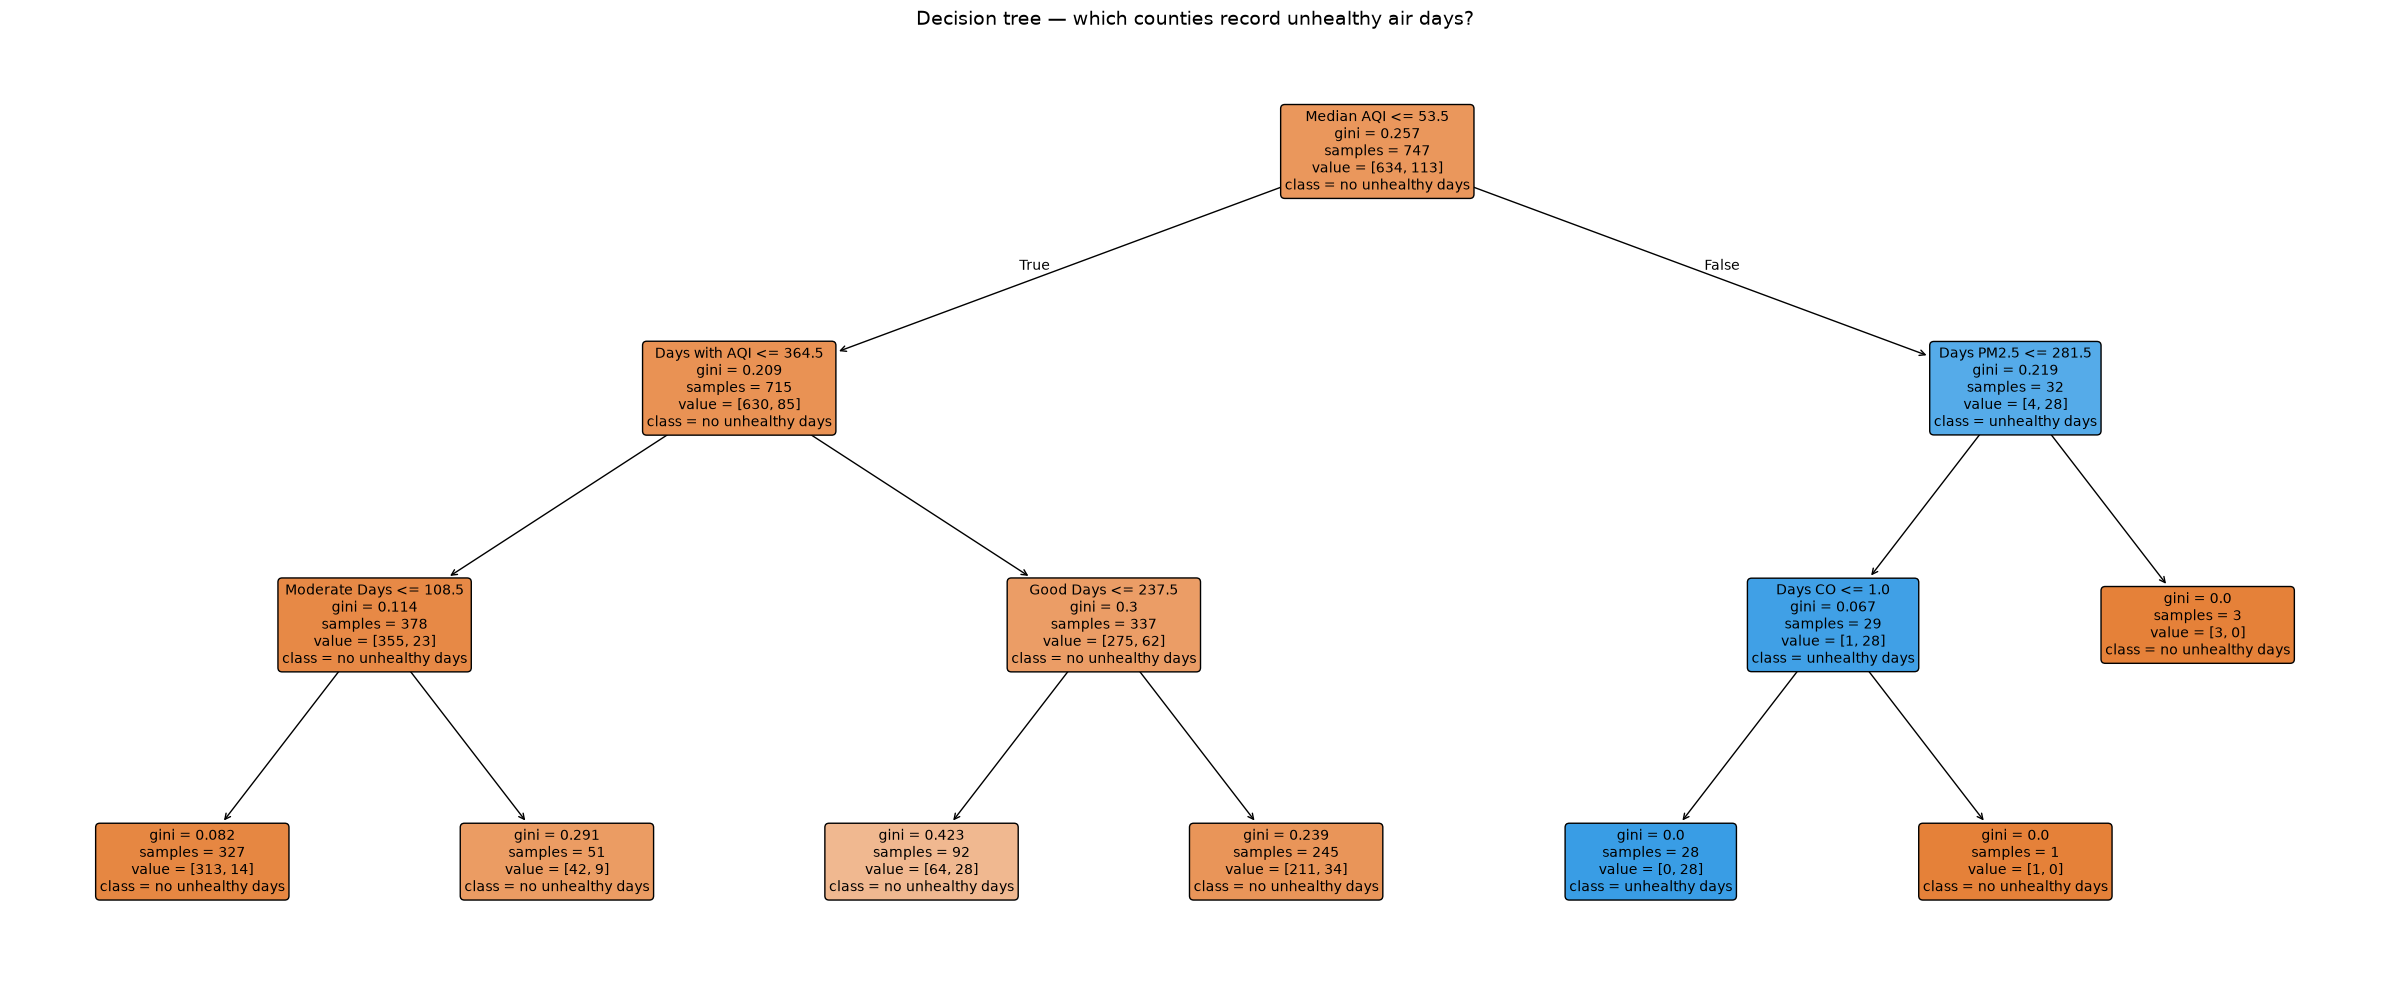

In [5]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(tree, ax=ax, feature_names=FEATURES,
          class_names=["no unhealthy days", "unhealthy days"],
          filled=True, rounded=True, fontsize=10, proportion=False)
plt.title("Decision tree — which counties record unhealthy air days?",
          fontsize=14)
plt.tight_layout(); plt.show()

**Reading it:** blue-ish boxes predict "no unhealthy days", orange/red
predicts "unhealthy days"; darker = purer. Follow one path from the root
to a leaf and say the rule out loud, e.g. *"Median AQI above 53.5 **and**
PM2.5 days at most 281 **and** CO days above 1 → unhealthy days."*

### Step 6 — What the tree relied on (provided)

Feature importances quantify which columns did the splitting work;
`export_text` prints the whole tree as indented rules you can paste into
a memo.

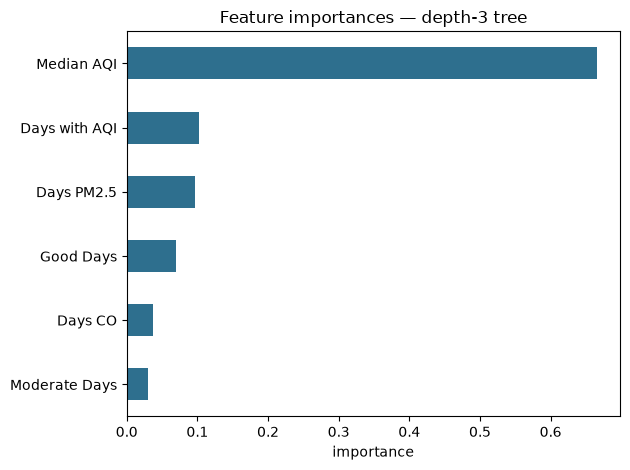

|--- Median AQI <= 53.50
|   |--- Days with AQI <= 364.50
|   |   |--- Moderate Days <= 108.50
|   |   |   |--- class: 0
|   |   |--- Moderate Days >  108.50
|   |   |   |--- class: 0
|   |--- Days with AQI >  364.50
|   |   |--- Good Days <= 237.50
|   |   |   |--- class: 0
|   |   |--- Good Days >  237.50
|   |   |   |--- class: 0
|--- Median AQI >  53.50
|   |--- Days PM2.5 <= 281.50
|   |   |--- Days CO <= 1.00
|   |   |   |--- class: 1
|   |   |--- Days CO >  1.00
|   |   |   |--- class: 0
|   |--- Days PM2.5 >  281.50
|   |   |--- class: 0



In [6]:
from sklearn.tree import export_text

importances = pd.Series(tree.feature_importances_, index=FEATURES) \
    .sort_values()
importances[importances > 0].plot.barh(
    color="#2e6f8e", title="Feature importances — depth-3 tree",
    xlabel="importance")
plt.tight_layout(); plt.show()

print(export_text(tree, feature_names=FEATURES))

### Step 7 — Your turn: let it grow wild

Remove the depth cap (`max_depth=None`), refit, and print train vs test
accuracy. Watch what happens: the tree keeps splitting until every leaf
is pure on the training data — and gets **worse** on counties it has
never seen. That gap is overfitting, made visible.

In [7]:
full_tree = None
# YOUR CODE: train a DecisionTreeClassifier with max_depth=None
# (random_state=42) on X_train/y_train, then print its train and test
# accuracy and its leaf count.

if full_tree is None:
    full_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
    full_tree.fit(X_train, y_train)
    print("(reference answer — replace with your own lines above)")
print(f"full tree: train={full_tree.score(X_train, y_train):.3f} "
      f"test={full_tree.score(X_test, y_test):.3f} "
      f"leaves={full_tree.get_n_leaves()}")

(reference answer — replace with your own lines above)
full tree: train=1.000 test=0.848 leaves=106


### Step 8 — The depth sweep: find the sweet spot

Train one tree per depth from 1 to 12 and chart train vs test accuracy.
The test curve peaks where the tree is complex enough to capture the
pattern but simple enough to generalize — that peak is your defensible
depth.

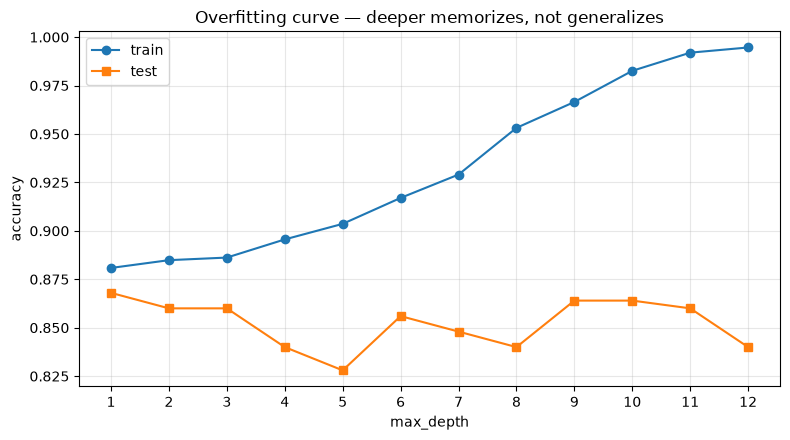

(using reference depth 3 — small, accurate, drawable; pick your own above)
chosen depth: 3


In [8]:
depths = list(range(1, 13))
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(depths, train_acc, "o-", label="train")
plt.plot(depths, test_acc, "s-", label="test")
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("Overfitting curve — deeper memorizes, not generalizes")
plt.xticks(depths); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_depth = None
# YOUR CODE: set best_depth to the depth you would defend (where test
# accuracy peaks, or just left of it for a simpler tree).

if best_depth is None:
    best_depth = 3
    print("(using reference depth 3 — small, accurate, drawable; "
          "pick your own above)")
print(f"chosen depth: {best_depth}")

## Deliverable
1. The depth-3 tree figure with one rule path read out in plain English.
2. Train vs test accuracy for the full (uncapped) tree, and one sentence
   naming what you just demonstrated.
3. Your chosen `best_depth` and the reason you would defend it to a
   reviewer.

## Reflection
1. The root split is on `Median AQI`. Why is a *median* a fair feature
   while `Max AQI` is leakage?
2. Which error would you rather minimize for an air-quality program —
   false positives or false negatives — and does plain accuracy capture
   that?
3. Where else in government would an auditable rules-box beat a slightly
   more accurate black box?

## Debrief (instructor-led)

- **Read one split per student.** Fastest way to feel the difference
  between a model and an *explanation*.
- **The leakage hunt.** Re-run with `Max AQI` added to FEATURES. Watch
  the score jump — then ask what the model actually learned.
- **Compare with Lab 1.2.** Clustering found groups without a label;
  this tree needs the label. What could each approach say that the other
  cannot?

## Troubleshooting

- **`FileNotFoundError: data/epa_aqi_by_county.csv`** — the kernel's
  working directory is not `labs/`. Restart the kernel from the `labs/`
  folder and Run All.
- **The tree figure is tiny/unreadable** — it renders large on purpose.
  Use the figure's pan/zoom controls in JupyterLab, or re-run the cell
  and read it with `export_text` from Step 6.
- **Accuracy looks different from a classmate's** — check that both of
  you kept `random_state=42` in the split and the classifier; the tree
  is deterministic only when the seed is.
- **`ValueError` on the sweep cell** — you probably edited `FEATURES`;
  re-run Steps 2–3 so X_train/X_test match the new column list.